<div style="background: linear-gradient(120deg, #1a3a5c 0%, #2d6a9f 60%, #4a9eda 100%); padding: 28px 36px; border-radius: 14px; display: flex; align-items: center; gap: 28px; box-shadow: 0 4px 18px rgba(0,0,0,0.18);">
    <img src='Figures/iteso.jpg' style="height: 110px; border-radius: 8px; background: white; padding: 6px; flex-shrink: 0; box-shadow: 0 2px 8px rgba(0,0,0,0.2);"/>
    <div style="border-left: 2px solid rgba(255,255,255,0.4); padding-left: 28px;">
        <h1 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Ingeniería y Ciencia de Datos</h1>
        <h3 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Laboratorio de Procesamiento de Datos</h3>
        <h3 style="margin: 0; color: rgba(255,255,255,0.8); font-weight: normal; font-size: 1.05em;">Módulo 1: Extracción de datos de diferentes fuentes: Archivos de Imagen</h3>
    </div>
</div>


# Archivos de imagen

Una imagen digital puede interpretarse como una matriz de píxeles. En una imagen RGB, la forma suele ser `(alto, ancho, 3)`: el último eje contiene los canales rojo, verde y azul. En imágenes con transparencia puede aparecer un cuarto canal alfa.

Leer una imagen como arreglo permite crear características numéricas, por ejemplo promedios de color, histogramas, bordes o texturas. Antes de modelar conviene revisar el rango de valores, el tipo de dato, la orientación y si todas las imágenes tienen la misma resolución.


Las imágenes RGB almacenan información de color en tres canales: Rojo (R), Verde (G) y Azul (B). Para leer y manipular imágenes en Python, se pueden usar las librerías:

| Librería | Ideal para | Lectura |
|---|---|---|
| **Pillow (PIL)** | manipulación general: abrir, convertir formatos, redimensionar, filtros simples | `Image.open()` |
| **imageio** | entrada/salida sencilla hacia `numpy` | `imageio.imread()` |
| **Matplotlib** | lectura rápida y **visualización** | `plt.imread()` / `plt.imshow()` |
| **OpenCV (cv2)** | visión por computadora, muy rápido, muchos algoritmos (¡usa orden **BGR**!) | `cv2.imread()` |
| **scikit-image (skimage)** | procesamiento científico: filtros, segmentación, umbralización | `skimage.io.imread()` |
| **scipy.ndimage** | filtros y transformaciones sobre arreglos n-dimensionales | opera sobre arreglos |

>  casi todas devuelven un `ndarray`. Una vez en ese formato, se puede **escalar (resize)**, **recortar (crop)**, **limitar valores (clip)**, **filtrar (desenfoque/bordes)**, **rotar** y **umbralizar**.

En los siguientes ejemplos usaremos la imagen `Data/madril.bmp`.


In [1]:
# Configuración común para ejecutar esta sección de forma independiente
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dir_base = os.getcwd()
print(dir_base)
ruta = os.path.join(dir_base, 'Data')
print(ruta)


C:\Users\uie70742\OneDrive - ITESO\ITESO\Ingeniería y Ciencia de Datos\Laboratorio_de_Procesamiento_de_Datos_02026\Modulo I
C:\Users\uie70742\OneDrive - ITESO\ITESO\Ingeniería y Ciencia de Datos\Laboratorio_de_Procesamiento_de_Datos_02026\Modulo I\Data


In [2]:
I=plt.imread(os.path.join(ruta,'mandril.png'))
I.shape

(512, 512)

In [4]:
type(I)

numpy.ndarray

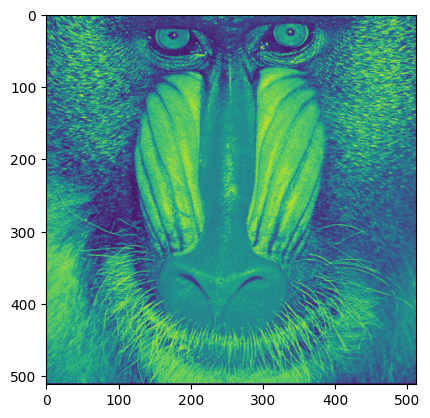

In [5]:
plt.imshow(I)

In [6]:
I[0,0] # pixel (0,0) de la matriz roja

np.float32(0.003921569)

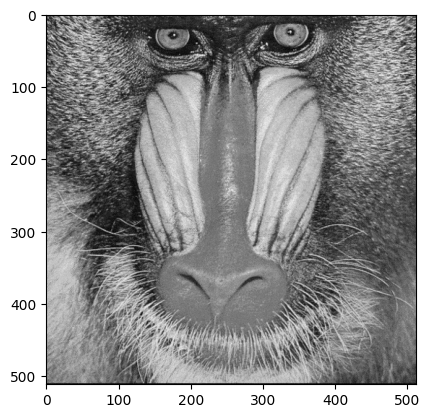

In [7]:
plt.imshow(I[:,:],cmap='gray') # Matriz roja

#### 1) NumPy puro

Como acabamos de ver con `I` y `G`, una imagen ya es un arreglo de NumPy: muchas operaciones no necesitan librerías extra. El **recorte** es *slicing*; el **volteo** es *slicing* con paso negativo; el **clip** limita los valores a un rango (evita que se "desborden" al ajustar el brillo). Partiendo de esta idea, veremos cómo cada librería especializada añade funciones más cómodas y potentes sobre el mismo arreglo.


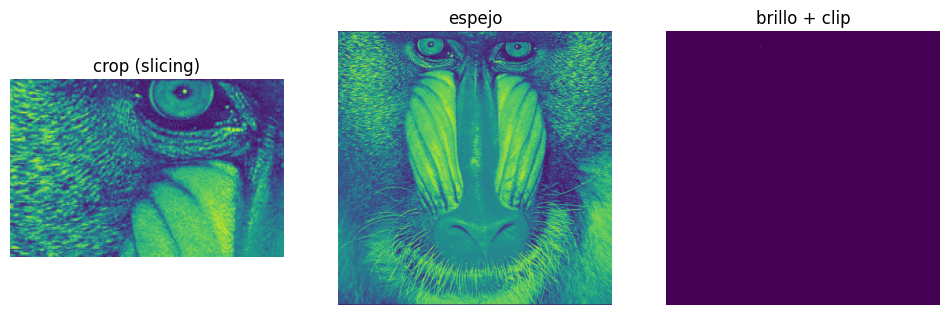

In [8]:
# Recorte, espejo y ajuste de brillo directamente sobre el arreglo `I` ya cargado
recorte  = I[20:150, 50:250]                        # crop por slicing [filas, columnas]
volteada = I[:, ::-1]                               # espejo horizontal
# Subir el brillo +10 y usar clip para no pasar de 255
brillo   = np.clip(I.astype(int) + 10, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(recorte);  ax[0].set_title('crop (slicing)'); ax[0].axis('off')
ax[1].imshow(volteada); ax[1].set_title('espejo');         ax[1].axis('off')
ax[2].imshow(brillo);   ax[2].set_title('brillo + clip');  ax[2].axis('off')
plt.show()


#### 2) Pillow (PIL)

Pillow trabaja con objetos `Image`. Permite conocer tamaño y modo de color, convertir a arreglo de NumPy y aplicar transformaciones encadenadas.

In [9]:
from PIL import Image, ImageFilter

img = Image.open(os.path.join(ruta, 'mandril.png'))
print('Tamaño (ancho, alto):', img.size)
print('Modo de color       :', img.mode)

# Un objeto Image se convierte a arreglo de NumPy con np.array
arr = np.array(img)
print('Forma como arreglo  :', arr.shape)

# Arreglos que reutilizaremos en el resto del notebook para evitar releer el archivo
img_rgb = np.array(img.convert('RGB'))
gris    = np.array(img.convert('L'))

Tamaño (ancho, alto): (512, 512)
Modo de color       : L
Forma como arreglo  : (512, 512)


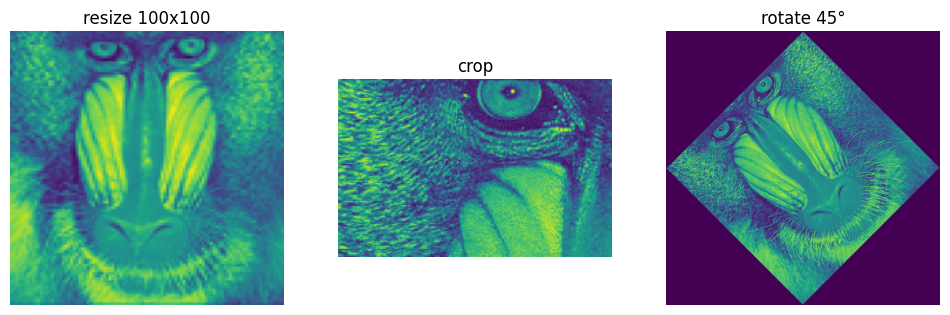

In [10]:
# Escalamiento (resize), recorte (crop) y rotación
img_pequena = img.resize((100, 100))        # forzar 100x100 px
img_recorte = img.crop((50, 20, 250, 150))  # (izq, arriba, der, abajo)
img_rotada  = img.rotate(45, expand=True)   # rotar 45°

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_pequena); ax[0].set_title('resize 100x100'); ax[0].axis('off')
ax[1].imshow(img_recorte); ax[1].set_title('crop');           ax[1].axis('off')
ax[2].imshow(img_rotada);  ax[2].set_title('rotate 45°');     ax[2].axis('off')
plt.show()

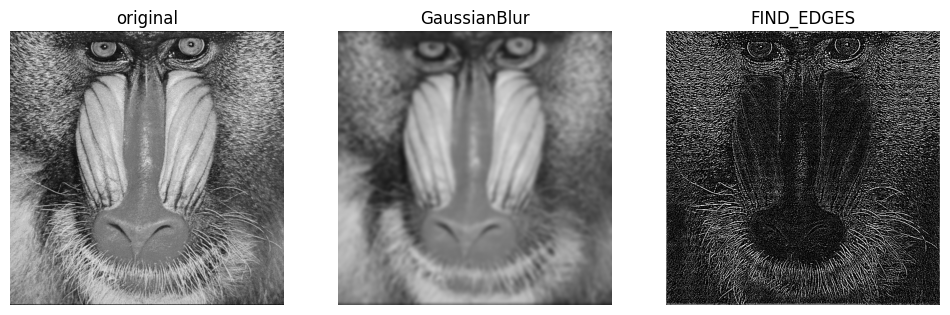

In [11]:
# Filtros integrados de Pillow: desenfoque y detección de bordes
img_pil_rgb = img.convert('RGB')
img_blur    = img_pil_rgb.filter(ImageFilter.GaussianBlur(radius=3))
img_edges   = img_pil_rgb.filter(ImageFilter.FIND_EDGES)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_pil_rgb); ax[0].set_title('original');     ax[0].axis('off')
ax[1].imshow(img_blur);    ax[1].set_title('GaussianBlur'); ax[1].axis('off')
ax[2].imshow(img_edges);   ax[2].set_title('FIND_EDGES');   ax[2].axis('off')
plt.show()

#### 3) imageio: lectura directa a NumPy

`imageio` es la forma más simple de pasar una imagen a un arreglo (y de guardarla). Es el motor de lectura que usan otras librerías por debajo.

Tipo : <class 'numpy.ndarray'>
Forma: (512, 512) | dtype: uint8


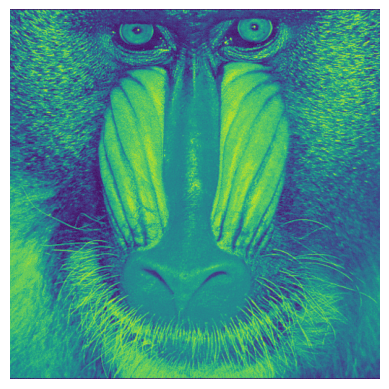

In [12]:
import imageio.v2 as imageio

img_arr = imageio.imread(os.path.join(ruta,'mandril.png'))
print('Tipo :', type(img_arr))
print('Forma:', img_arr.shape, '| dtype:', img_arr.dtype)
plt.imshow(img_arr); plt.axis('off'); plt.show()

#### 4) OpenCV (cv2)

OpenCV es el estándar en visión por computadora. Su única "trampa" es que lee los canales en orden **BGR** en vez de RGB, así que para visualizar con matplotlib hay que convertir con `cv2.cvtColor`.

Forma (alto, ancho, canales): (202, 300, 3)


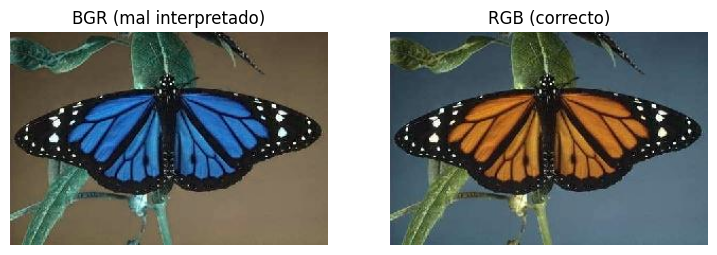

In [13]:
import cv2
import numpy as np

# cv2.imread falla con rutas que tienen acentos en Windows; leemos los bytes y decodificamos
img_bgr = cv2.imdecode(np.fromfile(os.path.join(ruta, 'butterfly.jpg'), dtype=np.uint8), cv2.IMREAD_COLOR)
img_rgb_cv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print('Forma (alto, ancho, canales):', img_bgr.shape)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(img_bgr);    ax[0].set_title('BGR (mal interpretado)'); ax[0].axis('off')
ax[1].imshow(img_rgb_cv); ax[1].set_title('RGB (correcto)');         ax[1].axis('off')
plt.show()


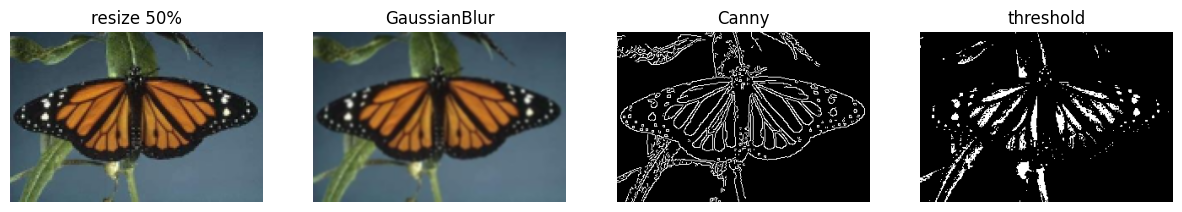

In [14]:
# Escalamiento, escala de grises, desenfoque, bordes (Canny) y umbralización
gris   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
escala = cv2.resize(img_rgb_cv, None, fx=0.5, fy=0.5)      # reducir 50%
desenf = cv2.GaussianBlur(img_rgb_cv, (7, 7), 0)
bordes = cv2.Canny(gris, 100, 200)
_, umbral = cv2.threshold(gris, 127, 255, cv2.THRESH_BINARY)

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
ax[0].imshow(escala);              ax[0].set_title('resize 50%');   ax[0].axis('off')
ax[1].imshow(desenf);              ax[1].set_title('GaussianBlur'); ax[1].axis('off')
ax[2].imshow(bordes, cmap='gray'); ax[2].set_title('Canny');        ax[2].axis('off')
ax[3].imshow(umbral, cmap='gray'); ax[3].set_title('threshold');    ax[3].axis('off')
plt.show()

#### Guardar el resultado

Todas las librerías pueden **escribir** imágenes: `img.save(...)` en Pillow, `cv2.imwrite(...)`, `imageio.imwrite(...)` o `plt.imsave(...)`. Así se persiste el resultado de un pipeline de procesamiento.

In [15]:
# Guardar una versión procesada (Pillow)
img_blur.save(ruta + 'imagen_procesada.png')
print('Imagen guardada en:', ruta + 'imagen_procesada.png')

Imagen guardada en: C:\Users\uie70742\OneDrive - ITESO\ITESO\Ingeniería y Ciencia de Datos\Laboratorio_de_Procesamiento_de_Datos_02026\Modulo I\Dataimagen_procesada.png


###  Operaciones con imágenes

Como una imagen es un arreglo, se pueden aplicar **operaciones aritméticas y lógicas** píxel a píxel: sumar/restar (brillo), multiplicar (contraste), mezclar dos imágenes, invertir colores (negativo) o aplicar máscaras. **NumPy** y **OpenCV** son las mejores opciones porque operan de forma vectorizada sobre el arreglo.

> **Cuidado con el desbordamiento:** en `uint8` los valores van de 0 a 255. Si sumas y superas 255, el valor "da la vuelta". Por eso se usa `np.clip` o funciones de OpenCV como `cv2.add` / `cv2.addWeighted`, que **saturan** en el límite.

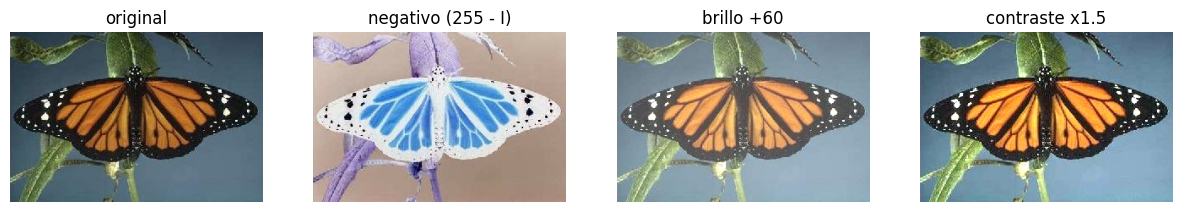

In [16]:
# Reutilizamos `img_rgb`, ya cargado en la sección de Pillow
negativo   = 255 - img_rgb_cv                                          # invertir colores
mas_brillo = np.clip(img_rgb_cv.astype(int) + 60, 0, 255).astype(np.uint8)
contraste  = np.clip(img_rgb_cv.astype(int) * 1.5, 0, 255).astype(np.uint8)   # x1.5

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, im, t in zip(ax, [img_rgb_cv, negativo, mas_brillo, contraste],
                    ['original', 'negativo (255 - I)', 'brillo +60', 'contraste x1.5']):
    a.imshow(im); a.set_title(t); a.axis('off')
plt.show()

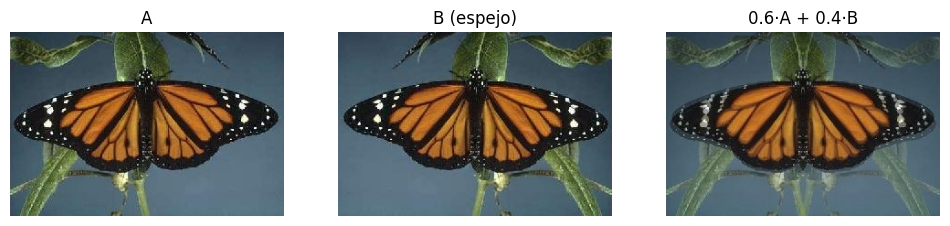

In [17]:
# Mezcla ponderada de dos imágenes (blending): alpha*A + beta*B
volteada = np.ascontiguousarray(img_rgb_cv[:, ::-1])            # segunda "imagen": espejo
mezcla = cv2.addWeighted(img_rgb_cv, 0.6, volteada, 0.4, 0)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_rgb_cv);  ax[0].set_title('A');              ax[0].axis('off')
ax[1].imshow(volteada); ax[1].set_title('B (espejo)');     ax[1].axis('off')
ax[2].imshow(mezcla);   ax[2].set_title('0.6·A + 0.4·B');  ax[2].axis('off')
plt.show()

In [18]:
gris

array([[ 44,  44,  43, ...,  60,  60,  60],
       [ 41,  42,  42, ...,  60,  60,  60],
       [ 40,  41,  43, ...,  61,  61,  61],
       ...,
       [ 78,  73,  71, ..., 106, 106, 106],
       [ 74,  70,  68, ..., 104, 104, 103],
       [ 74,  70,  68, ..., 104, 104, 103]], shape=(202, 300), dtype=uint8)

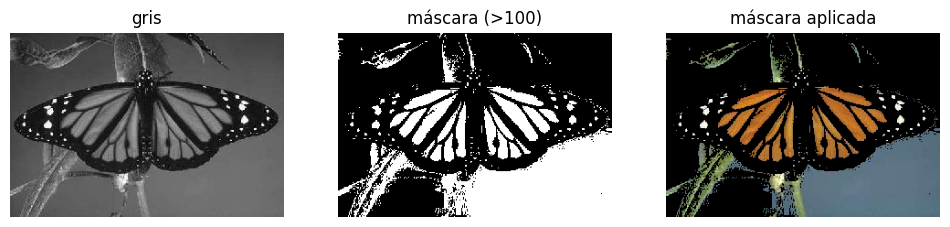

In [19]:
# Operación lógica con máscara: conservar solo los píxeles brillantes (reutilizamos `gris`)
mascara = gris > 100                                # True donde es brillante

resultado = img_rgb_cv.copy()
resultado[~mascara] = 0                             # apagar el resto

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(gris, cmap='gray');    ax[0].set_title('gris');            ax[0].axis('off')
ax[1].imshow(mascara, cmap='gray'); ax[1].set_title('máscara (>100)');  ax[1].axis('off')
ax[2].imshow(resultado);            ax[2].set_title('máscara aplicada');ax[2].axis('off')
plt.show()

###  Análisis de componentes

"Componentes" tiene dos sentidos en imágenes:

1. **Componentes de color:** los canales R, G y B. Analizarlos por separado y ver sus **histogramas** revela la distribución de intensidades y el color dominante.
2. **Componentes conexas:** grupos de píxeles vecinos que forman un mismo objeto. **Etiquetarlas** permite contar y medir objetos en una imagen binarizada.


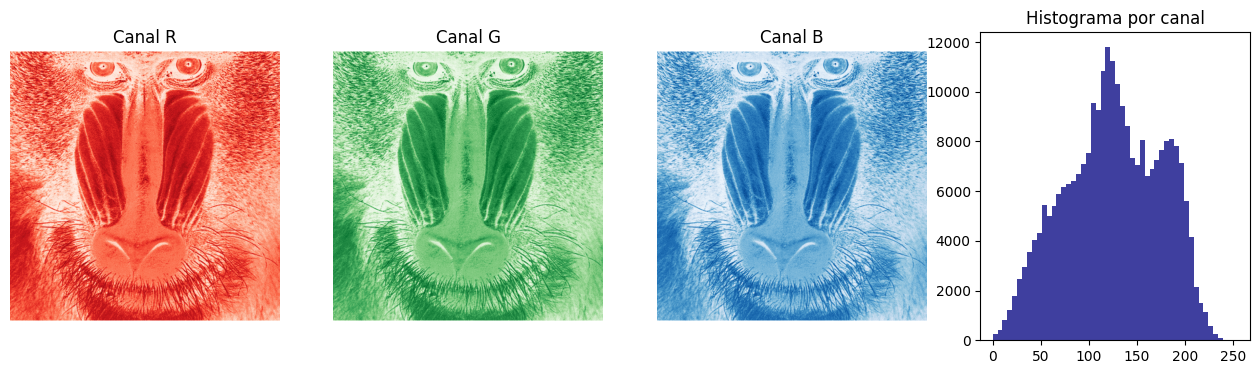

Intensidad media -> R: 125.0  G: 125.0  B: 125.0


In [20]:
# Componentes de color: separar canales y comparar sus histogramas (reutilizamos `img_rgb`)
R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(R, cmap='Reds');   ax[0].set_title('Canal R'); ax[0].axis('off')
ax[1].imshow(G, cmap='Greens'); ax[1].set_title('Canal G'); ax[1].axis('off')
ax[2].imshow(B, cmap='Blues');  ax[2].set_title('Canal B'); ax[2].axis('off')
for canal, c in zip([R, G, B], ['red', 'green', 'blue']):
    ax[3].hist(canal.ravel(), bins=50, color=c, alpha=0.5)
ax[3].set_title('Histograma por canal')
plt.show()

print('Intensidad media -> R: %.1f  G: %.1f  B: %.1f' % (R.mean(), G.mean(), B.mean()))

Número de componentes detectadas: 233


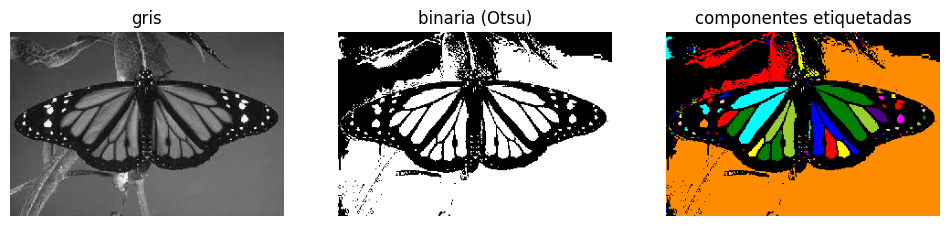

In [21]:
from skimage import measure, color as skcolor, filters

# Componentes conexas: binarizar y etiquetar los objetos (reutilizamos `gris`)
binaria = gris > filters.threshold_otsu(gris)          # binarización automática (Otsu)

etiquetas = measure.label(binaria)                     # etiquetar componentes conexas
print('Número de componentes detectadas:', etiquetas.max())

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(gris, cmap='gray');    ax[0].set_title('gris');           ax[0].axis('off')
ax[1].imshow(binaria, cmap='gray'); ax[1].set_title('binaria (Otsu)'); ax[1].axis('off')
ax[2].imshow(skcolor.label2rgb(etiquetas, bg_label=0)); ax[2].set_title('componentes etiquetadas'); ax[2].axis('off')
plt.show()

### Práctica de Laboratorio Procesamiento de Imagenes con Python

Consideremos la imagen (`Data/ITESO_entrance.jpg`), en este ejemplo encadenaremos varias de las operaciones vistas: lectura con OpenCV, corrección de canales, reescalamiento, composición (recorte + pegado) y rotación.


In [25]:
# Leer la imagen (imdecode por bytes: cv2.imread falla con rutas con acentos en Windows)
img_iteso_bgr = cv2.imdecode(np.fromfile(os.path.join(ruta, 'ITESO_entrance.jpg'), dtype=np.uint8), cv2.IMREAD_COLOR)
img_iteso_rgb = cv2.cvtColor(img_iteso_bgr, cv2.COLOR_BGR2RGB)
print('Forma (alto, ancho, canales):', img_iteso_rgb.shape)

Forma (alto, ancho, canales): (640, 960, 3)


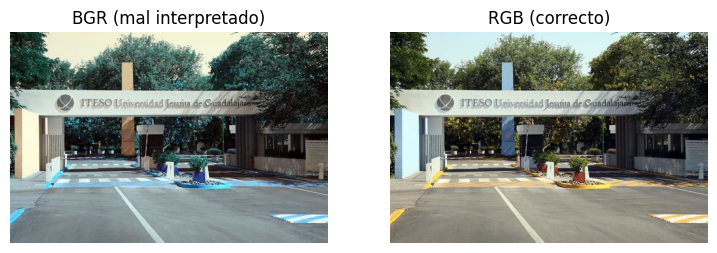

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(img_iteso_bgr);    ax[0].set_title('BGR (mal interpretado)'); ax[0].axis('off')
ax[1].imshow(img_iteso_rgb); ax[1].set_title('RGB (correcto)');         ax[1].axis('off')
plt.show()

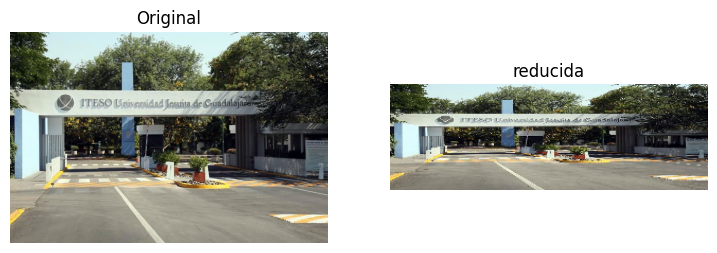

In [28]:
# Reescalamiento y composición: pegamos una copia reducida sobre una región recortada
iteso_reducida = cv2.resize(img_iteso_rgb, (300,100))
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(img_iteso_rgb);    ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(iteso_reducida); ax[1].set_title('reducida');         ax[1].axis('off')
plt.show()

In [29]:
iteso_reducida.shape

(100, 300, 3)

In [30]:
iteso_collage = img_iteso_rgb.copy()
iteso_collage[50:150, 100:400] = iteso_reducida


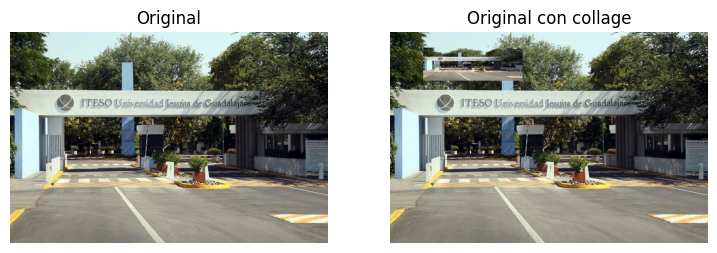

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(img_iteso_rgb);    ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(iteso_collage); ax[1].set_title('Original con collage');         ax[1].axis('off')
plt.show()

In [ ]:
# Rotación con OpenCV
cv2.rotate()

In [ ]:
# Canales de color e histogramas por canal
